# Classify Movements from IMU Data

## 1. Pre-processing

Define a utility function to read .bio files.

In [ ]:
import struct
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np

_DTYPE_MAP: dict[str, np.dtype] = {
    "?": np.dtype("bool"),
    "b": np.dtype("int8"),
    "B": np.dtype("uint8"),
    "h": np.dtype("int16"),
    "H": np.dtype("uint16"),
    "i": np.dtype("int32"),
    "I": np.dtype("uint32"),
    "q": np.dtype("int64"),
    "Q": np.dtype("uint64"),
    "f": np.dtype("float32"),
    "d": np.dtype("float64"),
}


@dataclass
class BioFile:
    """Parsed .bio file.  Each entry in `signals` has keys: data, fs."""

    path: Path
    signals: dict[str, dict] = field(default_factory=dict)
    metadata: dict = field(default_factory=dict)


def load_bio_file(file_path: str | Path) -> BioFile:
    """
    Read a .bio file produced by BioGUI's streaming controller.

    Returns a BioFile whose `signals` dict maps signal name -> dict with:
      data      : np.ndarray  shape (n_samp, n_ch)
      fs        : float       sampling rate [Hz]
      timestamp : np.ndarray  shape (n_samp_ts, 1) float64
                  biogui timestamps retrieved when a new data packet is received.

    Optional keys, present only for signals that actually recorded a trigger:
      trigger     : (n_samp_trigger, 1) uint32  gesture labels
      trigger_str : (n_samp_trigger, 1) object  gesture strings

    Timestamps and triggers are recorded per signal since different signals can arrive at different
    rates (e.g. multi-modal acquisitions).
    """
    file_path = Path(file_path)
    with open(file_path, "rb") as fh:
        n_signals = struct.unpack("<I", fh.read(4))[0]

        headers = []
        for _ in range(n_signals):
            name_len = struct.unpack("<I", fh.read(4))[0]
            name = struct.unpack(f"<{name_len}s", fh.read(name_len))[0].decode()
            fs, n_samp, n_ch, dtype_code, n_samp_ts, n_samp_trigger = struct.unpack(
                "<f2Ic2I", fh.read(21)
            )
            headers.append(
                {
                    "name": name,
                    "fs": float(fs),
                    "n_samp": int(n_samp),
                    "n_ch": int(n_ch),
                    "dtype": _DTYPE_MAP[dtype_code.decode("ascii")],
                    "n_samp_ts": int(n_samp_ts),
                    "n_samp_trigger": int(n_samp_trigger),
                }
            )

        signals: dict[str, dict] = {}
        has_trigger = False
        for h in headers:
            dt = h["dtype"]
            data = np.frombuffer(
                fh.read(dt.itemsize * h["n_samp"] * h["n_ch"]), dtype=dt
            ).reshape(h["n_samp"], h["n_ch"])

            ts = np.frombuffer(fh.read(8 * h["n_samp_ts"]), dtype=np.float64).reshape(
                h["n_samp_ts"], 1
            )

            sig: dict[str, object] = {"data": data, "fs": h["fs"], "timestamp": ts}

            if h["n_samp_trigger"]:
                has_trigger = True
                trig_ids = np.empty(h["n_samp_trigger"], dtype=np.uint32)
                trig_strs: list[str] = []
                for i in range(h["n_samp_trigger"]):
                    (trig_ids[i],) = struct.unpack("<I", fh.read(4))
                    (length,) = struct.unpack("<I", fh.read(4))
                    trig_strs.append(
                        fh.read(length).decode("utf-8", errors="replace")
                        if length
                        else ""
                    )
                sig["trigger"] = trig_ids.reshape(-1, 1)
                sig["trigger_str"] = np.array(trig_strs, dtype=object).reshape(-1, 1)

            signals[h["name"]] = sig

    metadata = {
        "n_signals": n_signals,
        "has_trigger": has_trigger,
    }
    print(
        f"Loaded {file_path.name}  signals={list(signals.keys())}  has_trigger={has_trigger}"
    )
    return BioFile(path=file_path, signals=signals, metadata=metadata)

Read .bio file with IMU data and inspect it.

In [ ]:
from pathlib import Path

biogui_path = Path("..", "biogui", "biogui")  # your path to the biogui folder
biofile_path = (
    biogui_path / "dataruntime" / "run_2026-07-23_17-57-02.bio"
)  # your path to the .bio file
biofile = load_bio_file(biofile_path)

for sig_name, sig in biofile.signals.items():
    print("-" * 50)
    print(f"Signal: {sig_name}")
    n_samp, n_ch = sig["data"].shape
    print(f"\tN. samples: {n_samp}")
    print(f"\tN. channels: {n_ch}")
    print(f"\tSampling rate: {sig['fs']:.2f} Hz")

    n_samp_ts = sig["timestamp"].shape[0]
    sig_ts_ratio = n_samp / n_samp_ts
    print(f"\tTimestamps: {n_samp_ts} (signal-to-timestamp ratio={sig_ts_ratio:.2f})")

    n_samp_trigger = sig["trigger"].shape[0] if "trigger" in sig else 0
    sig_trigger_ratio = n_samp / n_samp_trigger if n_samp_trigger > 0 else 0.0

    print(
        f"\tTriggers: {n_samp_trigger} (signal-to-trigger ratio={sig_trigger_ratio:.2f})"
    )

Loaded run_2026-07-23_17-57-02.bio  signals=['acc', 'gyro']  has_trigger=True
--------------------------------------------------
Signal: acc
	N. samples: 13844
	N. channels: 3
	Sampling rate: 104.00 Hz
	Timestamps: 3461 (signal-to-timestamp ratio=4.00)
	Triggers: 3461 (signal-to-trigger ratio=4.00)
--------------------------------------------------
Signal: gyro
	N. samples: 13844
	N. channels: 3
	Sampling rate: 104.00 Hz
	Timestamps: 3461 (signal-to-timestamp ratio=4.00)
	Triggers: 3461 (signal-to-trigger ratio=4.00)


As we can see, the `acc` and `gyro` signals have the same number of samples, so **no explicit alignment is needed**. The two timestamps and triggers have the same number of samples too, but 4x less compared to the actual signals.
This is expected, as the firmware, by design, sends a packet with 4 samples of `acc`, followed by a packet with 4 samples of `gyro`, and the BioGUI appends one timestamp and trigger value for each packet.

**If this were not the case** (e.g., the signals have different sampling rates, or come from different data sources), one would need to **align the signals using timestamps first**, and possibly resample to match the highest sampling rate.

We can now preprocess the signals by **resampling the triggers** and removing the edges corresponding to start and stop.

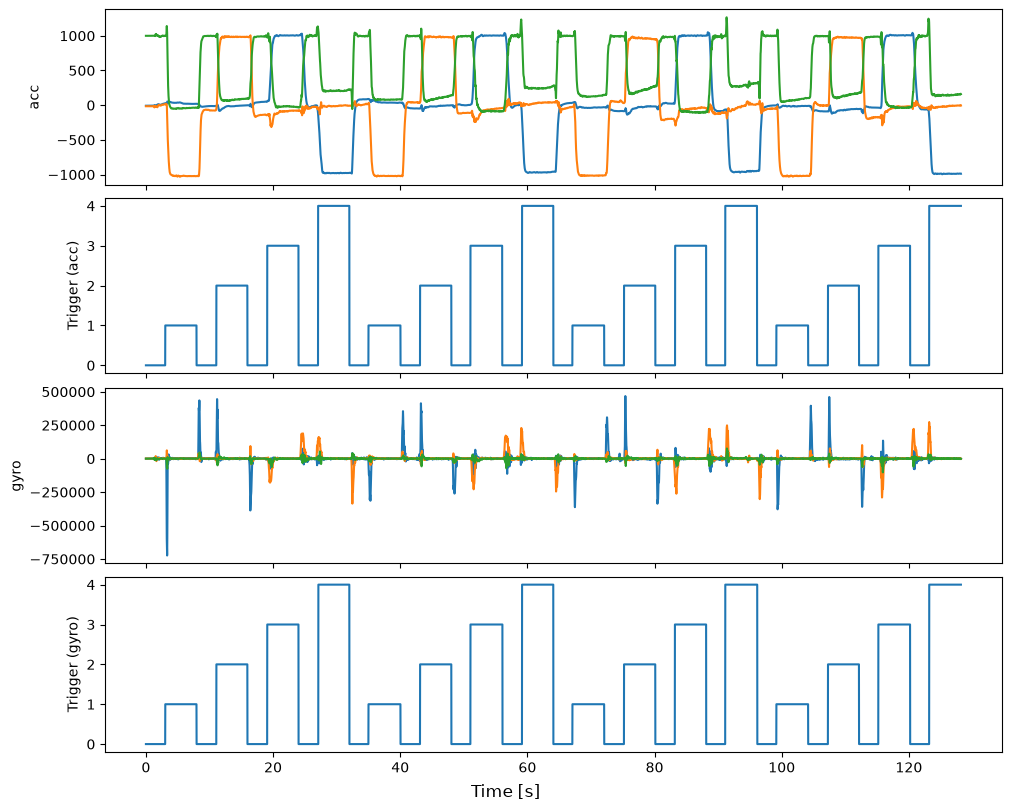

In [ ]:
from matplotlib import pyplot as plt

# Preprocess
edge_trigger = 0xFFFFFFFF
for sig_name, sig in biofile.signals.items():
    # Resample triggers
    n_samp = sig["data"].shape[0]
    n_samp_trigger = sig["trigger"].shape[0]
    sig_trigger_ratio = n_samp // n_samp_trigger
    sig["trigger"] = sig["trigger"].repeat(sig_trigger_ratio, axis=0)

    # Remove edge triggers
    sig["data"] = sig["data"][sig["trigger"].squeeze() != edge_trigger]
    sig["trigger"] = sig["trigger"][sig["trigger"].squeeze() != edge_trigger]

# Plot them
n_subs = sum([2 if "trigger" in sig else 1 for sig in biofile.signals.values()])
fig, axes = plt.subplots(
    n_subs, sharex="all", figsize=(10, 2 * n_subs), layout="constrained"
)
fig.supxlabel("Time [s]")

i = 0
t = np.arange(biofile.signals["acc"]["data"].shape[0]) / biofile.signals["acc"]["fs"]
for sig_name, sig in biofile.signals.items():
    axes[i].set_ylabel(sig_name)
    axes[i].plot(t, sig["data"])
    axes[i + 1].set_ylabel(f"Trigger ({sig_name})")
    axes[i + 1].plot(t, sig["trigger"])
    i += 2

plt.show()

We can unpack the two signals and use a single trigger from now on.

In [ ]:
fs = biofile.signals["acc"]["fs"]
acc = biofile.signals["acc"]["data"]
gyro = biofile.signals["gyro"]["data"]
trigger = biofile.signals["acc"]["trigger"].squeeze()

print(
    f"fs={fs}  acc.shape={acc.shape}  gyro.shape={gyro.shape}  trigger.shape={trigger.shape}"
)

fs=104.0  acc.shape=(13332, 3)  gyro.shape=(13332, 3)  trigger.shape=(13332,)


Instead of working on raw accelerometer and gyroscope data, we'll compute roll and pitch using a complementary filter.

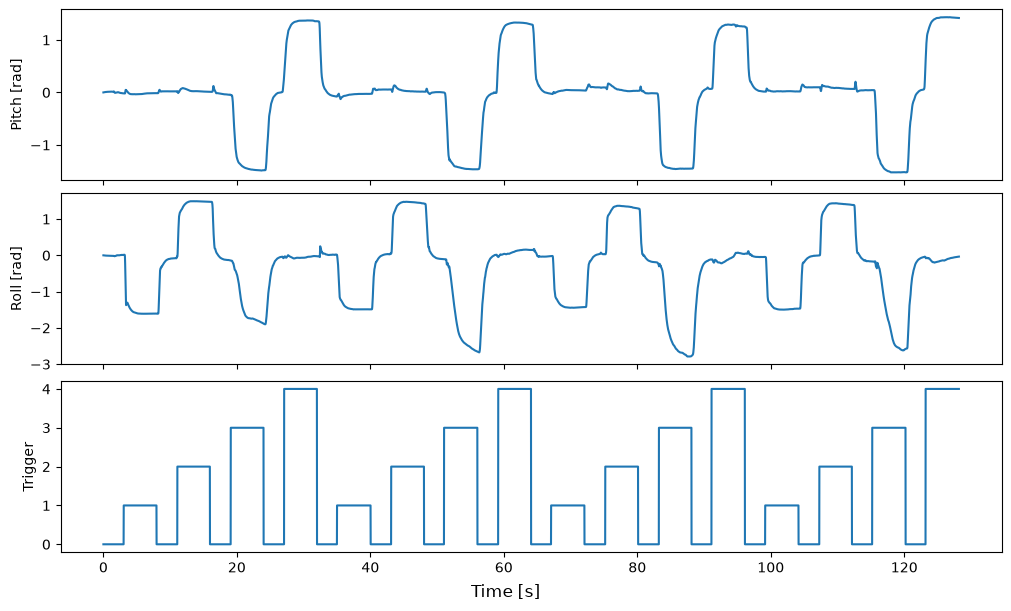

In [ ]:
from scipy import signal

# Convert units
acc = acc / 1000  # mg -> g
gyro = gyro * np.pi / 180_000  # mdps -> rad/s

# Filter accelerometer
sos = signal.butter(1, 10, "lowpass", output="sos", fs=fs)
acc_filt = signal.sosfilt(sos, acc, axis=0)

# Compute pitch and roll
ax = acc_filt[:, 0]
ay = acc_filt[:, 1]
az = acc_filt[:, 2]
pitch_acc = np.atan2(-ax, np.sqrt(ay**2 + az**2))
roll_acc = np.atan2(ay, az)

# Refine with gyroscope
gyro_x = gyro[:, 0]
gyro_y = gyro[:, 1]
dt = 1 / fs
alpha = 0.98
pitch = signal.lfilter(
    [1.0], [1.0, -alpha], alpha * dt * gyro_y + (1 - alpha) * pitch_acc
)
roll = signal.lfilter(
    [1.0], [1.0, -alpha], alpha * dt * gyro_x + (1 - alpha) * roll_acc
)

fig, axes = plt.subplots(3, 1, sharex="all", figsize=(10, 6), layout="constrained")
fig.supxlabel("Time [s]")
axes[0].set_ylabel("Pitch [rad]")
axes[0].plot(t, pitch)
axes[1].set_ylabel("Roll [rad]")
axes[1].plot(t, roll)
axes[2].set_ylabel("Trigger")
axes[2].plot(t, trigger)
plt.show()

## 2. Dataset preparation

Let's segment the trigger by repetition.

In [ ]:
def segment_repetitions(trigger_: np.ndarray) -> list[dict]:
    """Segment the trigger signal into repetitions of gestures."""
    # Detect transitions
    changes = np.flatnonzero(np.diff(trigger_)) + 1
    starts = np.r_[0, changes]
    ends = np.r_[changes, len(trigger_)]
    vals = trigger_[starts]

    # Assign repetition number
    rep_counters = {}  # gesture -> next rep index
    segments = []

    for v, s, e in zip(vals, starts, ends):
        rep_idx = rep_counters.get(v, 0) + 1
        rep_counters[v] = rep_idx
        segments.append(
            dict(gesture=int(v), rep_idx=int(rep_idx), start=int(s), end=int(e))
        )

    return segments


segments = segment_repetitions(trigger)
segments

[{'gesture': 0, 'rep_idx': 1, 'start': 0, 'end': 316},
 {'gesture': 1, 'rep_idx': 1, 'start': 316, 'end': 828},
 {'gesture': 0, 'rep_idx': 2, 'start': 828, 'end': 1152},
 {'gesture': 2, 'rep_idx': 1, 'start': 1152, 'end': 1660},
 {'gesture': 0, 'rep_idx': 3, 'start': 1660, 'end': 1984},
 {'gesture': 3, 'rep_idx': 1, 'start': 1984, 'end': 2496},
 {'gesture': 0, 'rep_idx': 4, 'start': 2496, 'end': 2816},
 {'gesture': 4, 'rep_idx': 1, 'start': 2816, 'end': 3328},
 {'gesture': 0, 'rep_idx': 5, 'start': 3328, 'end': 3640},
 {'gesture': 1, 'rep_idx': 2, 'start': 3640, 'end': 4164},
 {'gesture': 0, 'rep_idx': 6, 'start': 4164, 'end': 4484},
 {'gesture': 2, 'rep_idx': 2, 'start': 4484, 'end': 4996},
 {'gesture': 0, 'rep_idx': 7, 'start': 4996, 'end': 5308},
 {'gesture': 3, 'rep_idx': 2, 'start': 5308, 'end': 5828},
 {'gesture': 0, 'rep_idx': 8, 'start': 5828, 'end': 6152},
 {'gesture': 4, 'rep_idx': 2, 'start': 6152, 'end': 6664},
 {'gesture': 0, 'rep_idx': 9, 'start': 6664, 'end': 6976},
 {'g

Now, we concatenate `pitch` and `roll` into a single array with 2 channels, and create the dataset using a sliding window approach. Given a window size and step size, we'll produce:
- a `X` array with shape (n_windows, 2, window_size) containing the windowed IMU data;
- a `y` array with shape (n_windows,) containing the gesture label for each window;
- a `group` array with shape (n_windows,) containing the repetition index for each window.

The latter will be useful for a leave-one-repetition-out cross-validation scheme.

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

# Concatenate pitch and roll
imu_data = np.stack([pitch, roll], axis=1)

# Define window size
win_size_ms = 200
step_size_ms = 50
win_size = int(round(win_size_ms / 1000 * fs))
step_size = int(round(step_size_ms / 1000 * fs))

X, y = [], []
groups = []
for seg in segments:
    start, end = seg["start"], seg["end"]
    gesture = seg["gesture"]
    rep_idx = seg["rep_idx"]

    # Extract windows
    imu_data_win = imu_data[start:end]
    X.append(
        sliding_window_view(imu_data_win, win_size, axis=0)[::step_size].astype(
            np.float32
        )
    )
    y.append(np.repeat(gesture - 1, X[-1].shape[0]))
    groups.append(np.repeat(rep_idx, X[-1].shape[0]))

X = np.concatenate(X, dtype=np.float32)
y = np.concatenate(y, dtype=np.int64)
groups = np.concatenate(groups, dtype=np.int64)

print(f"X: {X.shape}, y: {y.shape}, groups: {groups.shape}")

X: (2550, 2, 21), y: (2550,), groups: (2550,)


Let's inspect the label and repetition count.

In [ ]:
unique_labels, label_counts = np.unique(y, return_counts=True)
min_reps = float("inf")
for label, count in zip(unique_labels, label_counts):
    in_reps = np.unique(groups[y == label])
    min_reps = min(min_reps, len(in_reps))
    print(f"Label {label}: {count} samples in reps {in_reps.tolist()}")
print(f"Minimum repetitions across all gestures: {min_reps}")

Label -1: 961 samples in reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Label 0: 400 samples in reps [1, 2, 3, 4]
Label 1: 394 samples in reps [1, 2, 3, 4]
Label 2: 397 samples in reps [1, 2, 3, 4]
Label 3: 398 samples in reps [1, 2, 3, 4]
Minimum repetitions across all gestures: 4


As we can see, the labels start from -1, which corresponds to "rest" and is far more frequent than the others. Therefore, we need to rebalance the dataset, and add +1 to the labels to start from zero.

In [ ]:
throw_away_ids = groups > min_reps

X = X[~throw_away_ids]
y = y[~throw_away_ids] + 1
groups = groups[~throw_away_ids]

unique_labels, label_counts = np.unique(y, return_counts=True)
for label, count in zip(unique_labels, label_counts):
    in_reps = np.unique(groups[y == label])
    print(f"Label {label}: {count} samples in reps {in_reps.tolist()}")

Label 0: 242 samples in reps [1, 2, 3, 4]
Label 1: 400 samples in reps [1, 2, 3, 4]
Label 2: 394 samples in reps [1, 2, 3, 4]
Label 3: 397 samples in reps [1, 2, 3, 4]
Label 4: 398 samples in reps [1, 2, 3, 4]


Lastly, we compute statistical features from the window size dimension.

In [ ]:
X_temp = []
for i in range(X.shape[0]):
    x_i = X[i]
    feat_i = np.concatenate(
        [
            np.mean(x_i, axis=-1),
            np.std(x_i, axis=-1),
            np.min(x_i, axis=-1),
            np.max(x_i, axis=-1),
        ]
    )
    X_temp.append(feat_i)
X = np.stack(X_temp, axis=0)

print("X:", X.shape)

X: (1831, 8)


## 3. Model training

In [11]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.svm import SVC
from skops import io as sio

# Iterate over repetitions
metrics = {}
logo = LeaveOneGroupOut()
for i, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    print(f"Fold {i}:")
    train_group = np.unique(groups[train_idx])
    test_group = np.unique(groups[test_idx])
    print(f"\tTrain groups: {train_group}")
    print(f"\tTest group: {test_group}")
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    print(f"\tX: {X_train.shape}, y: {y_train.shape} (training)")
    print(f"\tX: {X_test.shape}, y: {y_test.shape} (test)")

    # Train SVM
    svm = SVC(kernel="rbf", random_state=42)
    svm.fit(X_train, y_train)
    train_acc = svm.score(X_train, y_train)
    print(f"\tTrain accuracy: {train_acc:.2%}")

    # Evaluate
    test_acc = svm.score(X_test, y_test)
    print(f"\tTest accuracy: {test_acc:.2%}")

    # Store
    sio.dump(svm, Path("models", f"svm_fold_{i}.skops"))

    metrics[f"fold_{i}"] = dict(loss=train_acc, acc=test_acc)

print(f"Average train accuracy: {np.mean([m['loss'] for m in metrics.values()]):.2%}")
print(f"Average test accuracy: {np.mean([m['acc'] for m in metrics.values()]):.2%}")

Fold 0:
	Train groups: [2 3 4]
	Test group: [1]
	X: (1376, 8), y: (1376,) (training)
	X: (455, 8), y: (455,) (test)
	Train accuracy: 95.35%
	Test accuracy: 97.80%
Fold 1:
	Train groups: [1 3 4]
	Test group: [2]
	X: (1371, 8), y: (1371,) (training)
	X: (460, 8), y: (460,) (test)
	Train accuracy: 96.06%
	Test accuracy: 96.09%
Fold 2:
	Train groups: [1 2 4]
	Test group: [3]
	X: (1373, 8), y: (1373,) (training)
	X: (458, 8), y: (458,) (test)
	Train accuracy: 96.43%
	Test accuracy: 94.76%
Fold 3:
	Train groups: [1 2 3]
	Test group: [4]
	X: (1373, 8), y: (1373,) (training)
	X: (458, 8), y: (458,) (test)
	Train accuracy: 96.72%
	Test accuracy: 92.58%
Average train accuracy: 96.14%
Average test accuracy: 95.31%
